In [1]:
import numpy as np
import h5py as h5
from multiprocessing import Pool
import torch
import pickle as pk
import sys, os




In [2]:
from tqdm import tqdm

nrand_sel_box = 128
BoxSize = 25.
grid = 8
grid_sbox = 32
nvocab = 64
MAS_type = 'NGP'
snapnum = 90
ldir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH'

params_all = np.loadtxt('/projects/bdne/spandey3/GOTHAM/prep_data/camels_tng_LH_params.txt', usecols=range(1, 7))

def get_data(isim_fid, subsamp_ds=1):
    
    savefname_dmo_fields = f'{ldir}/DMO_fields/DMO_fields_grid_{grid_sbox}_isim_{isim_fid}_nrandsubsel_{nrand_sel_box}_MAS_{MAS_type}_nsnaps_5.pkl'
    saved = pk.load(open(savefname_dmo_fields, 'rb'))
    dmo_fields = saved['dmo_fields_all']
    rand_sel = saved['rand_sel']

    savefname_gals = f'{ldir}/gal_props/galaxy_props_snap_{snapnum}_grid_{nvocab}_isim_{isim_fid}_nrandsubsel_{nrand_sel_box}_nvocab{nvocab}_wSDSS_photometry_velx.pkl'
    saved = pk.load(open(savefname_gals, 'rb'))
    story_full = saved['story_full']

    if subsamp_ds>1:
        nsel = int(len(rand_sel)/subsamp_ds)
        story_full = story_full[:nsel,...]
        dmo_fields = dmo_fields[:nsel,...]
        rand_sel = rand_sel[:nsel]

    params = params_all[isim_fid][None,:]
    params_repeated = np.repeat(params, len(rand_sel), axis=0)
    return params_repeated, dmo_fields, story_full

def get_data_all_mat(isim_start, isim_end, subsamp_ds):
    params_repeated_all, dmo_fields_all, story_full_all = [], [], []        
    for isim_fid in tqdm(range(isim_start, isim_end)):
        params_repeated_i, dmo_fields_i, story_full_i = get_data(isim_fid, subsamp_ds)
        params_repeated_all.append(params_repeated_i)
        dmo_fields_all.append(dmo_fields_i)
        story_full_all.append(story_full_i)
    
    params_repeated_all = np.concatenate(params_repeated_all, axis=0)
    dmo_fields_all = torch.moveaxis(torch.Tensor(np.concatenate(dmo_fields_all, axis=0)).to(torch.float16), -1, 1)
    story_full_all = np.concatenate(story_full_all, axis=0)

    x = torch.tensor(story_full_all[:, :-1])
    y = torch.tensor(story_full_all[:, 1:])
    mask = torch.logical_not(x != 1)
    masked_logits = torch.zeros(mask.shape)
    mask_final = masked_logits.masked_fill(mask, float('-inf'))
    mask = mask_final[:,None,:]
    x = x.to(torch.long)
    y = y.to(torch.long)
    params_all = torch.tensor(params_repeated_all).to(torch.float16)
    mask = torch.tensor(mask).to(torch.float16)
    
    return x, y, dmo_fields_all, params_all, mask
    


In [10]:
train_fac = 0.75
val_fac = 0.175
test_fac = 0.075
subsamp_ds = 2

n_gpus = 4
nsims_tot = 1000
sims_per_gpu = nsims_tot//n_gpus
train_sims_per_gpu = int(train_fac * sims_per_gpu)
val_sims_per_gpu = int(val_fac * sims_per_gpu)

sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/process_split'
savefname = f'{sdir}/SPLIT_DATA_{n_gpus}_gpus_nspersim_subhalo_density3Dgrid_{grid_sbox}_isim_all_nrandsubsel_{int(nrand_sel_box/subsamp_ds)}_nvocab{nvocab}_wSDSS_photometry_gri_velx_hres.h5'
dtype = 'float16'
fo = h5.File(savefname, 'w')
# with h5.File(savefname, 'w') as fo:    
for ji in range(n_gpus):
    id_train_start = ji*sims_per_gpu
    id_train_end = id_train_start + train_sims_per_gpu

    id_val_start = id_train_end
    id_val_end = id_val_start + val_sims_per_gpu

    x_train, y_train, dm_train, params_train, mask_train = get_data_all_mat(id_train_start, id_train_end, subsamp_ds)
    x_val, y_val, dm_val, params_val, mask_val = get_data_all_mat(id_val_start, id_val_end, subsamp_ds)        

    fo.create_dataset(f'x_train_dev_{ji}', data=x_train)
    fo.create_dataset(f'dm_train_dev_{ji}', data=dm_train)
    fo.create_dataset(f'params_train_dev_{ji}', data=params_train)
    fo.create_dataset(f'mask_train_dev_{ji}', data=mask_train)
    fo.create_dataset(f'y_train_dev_{ji}', data=y_train)

    fo.create_dataset(f'x_val_dev_{ji}', data=x_val)
    fo.create_dataset(f'dm_val_dev_{ji}', data=dm_val)
    fo.create_dataset(f'params_val_dev_{ji}', data=params_val)
    fo.create_dataset(f'mask_val_dev_{ji}', data=mask_val)
    fo.create_dataset(f'y_val_dev_{ji}', data=y_val)


savefname_gals = f'{ldir}/gal_props/galaxy_props_snap_{snapnum}_grid_{nvocab}_isim_{0}_nrandsubsel_{nrand_sel_box}_nvocab{nvocab}_wSDSS_photometry_velx.pkl'
saved = pk.load(open(savefname_gals, 'rb'))
start_token, pad_token, end_token, max_sentence_length = saved['start_token'], saved['pad_token'], saved['end_token'], saved['max_sentence_length']
nvocab_total = end_token + 1
fo.create_dataset('nvocab_total', data=nvocab_total)
fo.create_dataset('grid', data=grid_sbox)
fo.create_dataset('start_token', data=start_token)
fo.create_dataset('pad_token', data=pad_token)
fo.create_dataset('end_token', data=end_token)
fo.create_dataset('max_sentence_length', data=max_sentence_length)
fo.close()






100%|██████████| 187/187 [03:00<00:00,  1.04it/s]
/tmp/ipykernel_3607618/2999082698.py:56: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask).to(torch.float16)
100%|██████████| 43/43 [00:57<00:00,  1.34s/it]


In [13]:
import matplotlib.pyplot as pl
%matplotlib inline


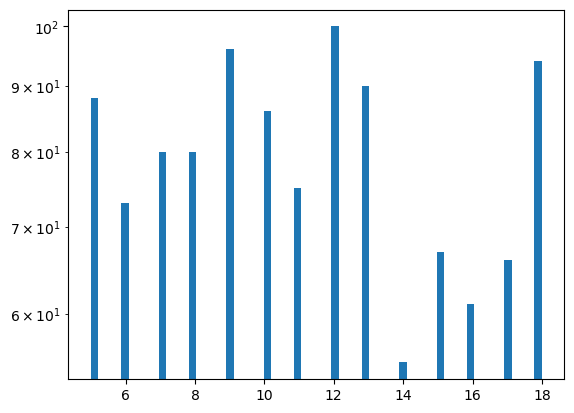

In [89]:
# x_train.shape
pl.figure()
_ = pl.hist(x_train[:,3], bins=60, range=(5,18))

pl.yscale('log')




In [61]:
# x_train[313,:]
indp = np.where(x_train[:,-8] == 68)[0]


In [52]:
xall = (np.linspace(0, BoxSize/grid, nvocab + 1))
xarray = 0.5 * (xall[1:] + xall[:-1])
yarray = np.copy(xarray)
zarray = np.copy(xarray)

prop_min = np.array([7.5, 26, 26, 26, -0.5])
prop_max = np.array([11.5, 30, 30, 30, 0.5])

bins_digitize = np.linspace(-1e-3, 1, nvocab)
bins_digitize = np.insert(bins_digitize, 0, -1)
delta_bin = bins_digitize[5] - bins_digitize[4]


In [71]:
pos_infer_all = []
prop_infer_all = []

dim_prop = 5
dim_pos = 3
ntokens_per_halo = 8
# jx, jy, jz = 0, 5, 2
# jx, jy, jz = 0, 5, 0
# for jx in range(grid):
#     for jy in range(grid):
#         for jz in range(grid):
sentence_here = x_train[indp[4],:]
ind_start_token = np.where(sentence_here == start_token)[0]
if end_token in sentence_here:
    ind_end_token = np.where(sentence_here == end_token)[0]
    Nhalos_here = ((ind_end_token - ind_start_token - 1) / ntokens_per_halo)[0]
    if (int(Nhalos_here) - Nhalos_here) != 0:
        print('Nhalos_here is not an integer')
    else:
        if Nhalos_here > 0:
            for jh in range(int(Nhalos_here)):
                coord_x = (xarray[sentence_here[ind_start_token + jh*ntokens_per_halo + 1]] + (BoxSize/grid)*0) % BoxSize
                coord_y = (yarray[sentence_here[ind_start_token + jh*ntokens_per_halo + 2]] + (BoxSize/grid)*0) % BoxSize
                coord_z = (zarray[sentence_here[ind_start_token + jh*ntokens_per_halo + 3]] + (BoxSize/grid)*0) % BoxSize


                pos_infer_all.append([coord_x, coord_y, coord_z])
                prop_all = np.zeros(dim_prop)
                for jp in range(dim_prop):
                    # noise_val = np.random.uniform(-delta_bin/2, delta_bin/2)
                    noise_val = 0
                    bin_val_jp = sentence_here[ind_start_token + jh*ntokens_per_halo + 4 + jp]
                    prop_all[jp] = prop_min[jp] + (prop_max[jp] - prop_min[jp]) * (bins_digitize[bin_val_jp] + noise_val)
                prop_infer_all.append(prop_all)

pos_infer_all = np.array(pos_infer_all)
prop_infer_all = np.array(prop_infer_all)



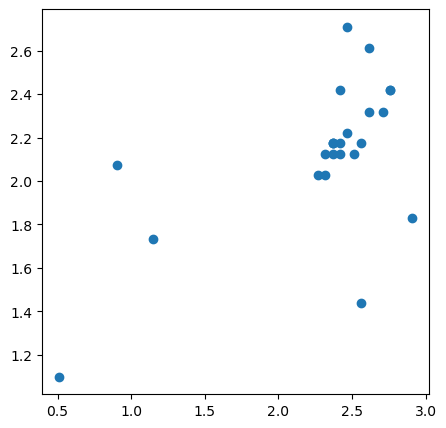

In [72]:
pl.figure(figsize=(5,5))
pl.scatter(pos_infer_all[:,0], pos_infer_all[:,1])


In [85]:
# Ndevices = 4
# sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/process_split'
# savefname = f'{sdir}/SPLIT_DATA_{Ndevices}_gpus_nspersim_subhalo_density3Dgrid_{grid_sbox}_isim_all_nrandsubsel_{int(nrand_sel_box/subsamp_ds)}_nvocab{nvocab}_wSDSS_photometry_gri_velx_hres_0.h5'
# fo1 = h5.File(savefname, 'r')
# savefname = f'{sdir}/SPLIT_DATA_{Ndevices}_gpus_nspersim_subhalo_density3Dgrid_{grid_sbox}_isim_all_nrandsubsel_{int(nrand_sel_box/subsamp_ds)}_nvocab{nvocab}_wSDSS_photometry_gri_velx_hres.h5'
# fo = h5.File(savefname, 'w')
# fo.create_dataset('nvocab_total', data=nvocab_total)
# fo.create_dataset('grid', data=grid_sbox)
# fo.create_dataset('start_token', data=start_token)
# fo.create_dataset('pad_token', data=pad_token)
# fo.create_dataset('end_token', data=end_token)
# fo.create_dataset('max_sentence_length', data=max_sentence_length)


# for ji in range(4):
#     fo.create_dataset(f'x_train_dev_{ji}', data=fo1[f'x_train_dev_{ji}'][:])
#     fo.create_dataset(f'dm_train_dev_{ji}', data=torch.moveaxis(torch.Tensor(fo1[f'dm_train_dev_{ji}'][:]), -1, 1))
#     fo.create_dataset(f'params_train_dev_{ji}', data=fo1[f'params_train_dev_{ji}'][:])
#     fo.create_dataset(f'mask_train_dev_{ji}', data=fo1[f'mask_train_dev_{ji}'][:])
#     fo.create_dataset(f'y_train_dev_{ji}', data=fo1[f'y_train_dev_{ji}'][:])

#     fo.create_dataset(f'x_val_dev_{ji}', data=fo1[f'x_val_dev_{ji}'][:])
#     fo.create_dataset(f'dm_val_dev_{ji}', data=torch.moveaxis(torch.Tensor(fo1[f'dm_val_dev_{ji}'][:]), -1, 1))
#     fo.create_dataset(f'params_val_dev_{ji}', data=fo1[f'params_val_dev_{ji}'][:])
#     fo.create_dataset(f'mask_val_dev_{ji}', data=fo1[f'mask_val_dev_{ji}'][:])
#     fo.create_dataset(f'y_val_dev_{ji}', data=fo1[f'y_val_dev_{ji}'][:])
    
# fo.close()
# fo1.close()


In [87]:
# ji = 0
# sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/process_split'
# savefname = f'{sdir}/SPLIT_DATA_{Ndevices}_gpus_nspersim_subhalo_density3Dgrid_{grid_sbox}_isim_all_nrandsubsel_{int(nrand_sel_box/subsamp_ds)}_nvocab{nvocab}_wSDSS_photometry_gri_velx_hres.h5'
# fo2 = h5.File(savefname, 'r')
# print(fo2[f'dm_val_dev_{ji}'][:].shape)
# fo2.close()


(2752, 30, 32, 32, 32)


In [83]:
# /work/hdd/bdne/spandey3/camels_tng/gotham_data/process_split/SPLIT_DATA_4_gpus_nspersim_subhalo_density3Dgrid_32_isim_all_nrandsubsel_32_nvocab128_wSDSS_photometry_gri_velx_hres.h5

# /work/hdd/bdne/spandey3/camels_tng/gotham_data/process_split/SPLIT_DATA_4_gpus_nspersim_subhalo_density3Dgrid_32_isim_all_nrandsubsel_64_nvocab64_wSDSS_photometry_gri_velx_hres.h5
# nvocab_total
# ji = 0
# torch.moveaxis(torch.Tensor(fo1[f'dm_train_dev_{ji}'][:]), -1, 1).shape



torch.Size([11968, 30, 32, 32, 32])